# Session 3: Large Language Models

Large language models (LLMs) are neural networks trained to predict the next token in a sequence. That deceptively simple objective produces surprisingly broad capabilities: commonsense reasoning, question answering, summarization, code generation, and instruction following. Modern LLM workflows usually combine three stages: loading a pretrained model, measuring its performance on a targeted task, and then finetuning it so that the model adapts to the specific patterns we need.

In this session we build a compact end-to-end workflow around **Qwen 2.5 3B Instruct**, a capable open-weight instruction-tuned model:

1. **Explore tokenization** — understand how text becomes tokens and why it matters.
2. **Understand autoregressive generation** — see how decoding strategy changes model output.
3. **Frame MMLU as an instruction task** — a challenging multiple-choice benchmark spanning 57 academic subjects.
4. **Evaluate the pretrained model** and improve it through prompting alone (in-context learning).
5. **Finetune with LoRA** on a small subset and compare accuracy before and after.
6. **Call the OpenAI API** for inference with a hosted frontier model.

By the end you will have seen the full LLM lifecycle: tokenization → autoregressive generation → task framing → in-context learning → parameter-efficient finetuning → hosted API inference.

## 0. Setup

We use **Transformers** for model loading, **datasets** for data access, **PEFT** for parameter-efficient finetuning, and **Matplotlib** for visualization. This notebook is designed to run on an A100 GPU in Google Colab — Qwen 2.5 3B fits comfortably in `float16` on a single A100.

We redirect the Hugging Face cache to a local runtime directory so that re-runs skip redundant downloads.

The final section uses the OpenAI API. Before running that cell, set `OPENAI_API_KEY` in your environment.

In [1]:
! pip install -q transformers datasets accelerate peft trl openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 16.5 MB/s eta 0:00:00


In [13]:
%matplotlib inline

import inspect
import os
import random
import re
from collections import Counter
from pathlib import Path

IN_COLAB = 'google.colab' in str(get_ipython())
RUNTIME_ROOT = Path('/content' if IN_COLAB else '.').resolve()
HF_CACHE_ROOT = RUNTIME_ROOT / 'hf_cache'
HF_HUB_CACHE = HF_CACHE_ROOT / 'hub'
HF_DATASETS_CACHE = HF_CACHE_ROOT / 'datasets'
OUTPUT_ROOT = RUNTIME_ROOT / 'artifacts'

HF_HUB_CACHE.mkdir(parents=True, exist_ok=True)
HF_DATASETS_CACHE.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

os.environ['HF_HOME'] = str(HF_CACHE_ROOT)
os.environ['HUGGINGFACE_HUB_CACHE'] = str(HF_HUB_CACHE)
os.environ['HF_HUB_CACHE'] = str(HF_HUB_CACHE)
os.environ['TRANSFORMERS_CACHE'] = str(HF_HUB_CACHE)
os.environ['HF_DATASETS_CACHE'] = str(HF_DATASETS_CACHE)

import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from peft import LoraConfig, TaskType, get_peft_model
from transformers import AutoModelForCausalLM, AutoTokenizer, Trainer, TrainingArguments, default_data_collator

SEED = 0
random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type != 'cuda':
    print('WARNING: A CUDA GPU is strongly recommended.')
print(f'Runtime root : {RUNTIME_ROOT}')
print(f'HF cache     : {HF_CACHE_ROOT}')
print(f'Artifacts    : {OUTPUT_ROOT}')

Using device: cuda
Runtime root : /content
HF cache     : /content/hf_cache
Artifacts    : /content/artifacts


---

## 1. Load the Model and Tokenizer

We work with **Qwen2.5-3B-Instruct**, a 3-billion-parameter instruction-tuned model from Alibaba's Qwen team. At this size it shows strong commonsense and science reasoning while still being practical to finetune.

We load the model in `float16` on the GPU and define a helper that applies the model's built-in **chat template** — the function that converts a list of `{"role": ..., "content": ...}` messages into the exact token string the model was trained to expect. Different models use different templates, which is why using `apply_chat_template` is always safer than hand-crafting delimiters.

In [14]:
MODEL_NAME = 'Qwen/Qwen2.5-3B-Instruct'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'

torch_dtype = torch.float16 if device.type == 'cuda' else torch.float32
base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch_dtype)
base_model.to(device)
base_model.eval()

SYSTEM_PROMPT = (
    'You are a science reasoning assistant. '
    'Answer multiple-choice questions with exactly one letter: A, B, C, or D.'
)

def render_messages(messages, add_generation_prompt=False):
    if tokenizer.chat_template is not None:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=add_generation_prompt,
        )
    prompt = ''
    for msg in messages:
        prompt += f"{msg['role'].upper()}: {msg['content']}\n"
    if add_generation_prompt:
        prompt += 'ASSISTANT: '
    return prompt

total_params = sum(p.numel() for p in base_model.parameters())
print(f'Model        : {MODEL_NAME}')
print(f'Parameters   : {total_params / 1e9:.2f}B')
print(f'Vocab size   : {tokenizer.vocab_size:,}')
print(f'dtype        : {torch_dtype}')

# Preview what a chat-templated prompt looks like
preview = render_messages(
    [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': 'What gas do plants absorb?\nA) Oxygen\nB) Carbon dioxide\nC) Nitrogen\nD) Hydrogen\nAnswer with exactly one letter.'},
    ],
    add_generation_prompt=True,
)
print('\nSample chat-templated prompt:\n')
print(preview[:600])

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Model        : Qwen/Qwen2.5-3B-Instruct
Parameters   : 3.09B
Vocab size   : 151,643
dtype        : torch.float16

Sample chat-templated prompt:

<|im_start|>system
You are a science reasoning assistant. Answer multiple-choice questions with exactly one letter: A, B, C, or D.<|im_end|>
<|im_start|>user
What gas do plants absorb?
A) Oxygen
B) Carbon dioxide
C) Nitrogen
D) Hydrogen
Answer with exactly one letter.<|im_end|>
<|im_start|>assistant



### 1.1 Tokenization Explorer

Before evaluating or finetuning a model it is worth understanding what a *token* actually is. LLMs do not read characters or words — they read **tokens**: units produced by a **Byte-Pair Encoding (BPE)** algorithm that compresses frequent character sequences into single symbols. Qwen 2.5 has a vocabulary of ~150 K tokens.

A few things worth noticing in the cell below:

- Common English words are usually a single token; rare or technical words are split into subwords.
- **Numbers are tokenized digit-by-digit or in small groups** — a key reason why arithmetic is hard for LLMs without special training.
- The same content written differently uses different token counts, which affects both cost (API pricing) and performance.
- Special tokens like `<|im_start|>` and `<|im_end|>` (Qwen's "Instruction Markup") delimit role boundaries in the chat template and are never seen during normal text generation.

In [15]:
# ── 1.1  tokenization Explorer ───────────────────────────────────────────────

examples = [
    "The cat sat on the mat.",
    "Photosynthesis converts carbon dioxide and water into glucose.",
    "2025 + 1337 = 3362",
    "Supercalifragilisticexpialidocious",
    "I love deep learning!",
]

print(f"Vocabulary size : {tokenizer.vocab_size:,}")
print(f"Special tokens  : {tokenizer.all_special_tokens[:8]} …")
print()

for text in examples:
    ids    = tokenizer.encode(text, add_special_tokens=False)
    tokens = [tokenizer.decode([i]) for i in ids]
    print(f"Text   : {text}")
    print(f"Tokens : {tokens}")
    print(f"IDs    : {ids}")
    print(f"Count  : {len(ids)} tokens")
    print()

# Show how the chat template adds special structure tokens
demo_messages = [
    {'role': 'system', 'content': SYSTEM_PROMPT},
    {'role': 'user',   'content': 'What is the boiling point of water?'},
]
templated     = render_messages(demo_messages, add_generation_prompt=True)
templated_ids = tokenizer.encode(templated)
print("─" * 60)
print("Chat-templated prompt (rendered):\n")
print(templated)
print(f"Total tokens after templating: {len(templated_ids)}")

Vocabulary size : 151,643
Special tokens  : ['<|im_end|>', '<|endoftext|>', '<|im_start|>', '<|object_ref_start|>', '<|object_ref_end|>', '<|box_start|>', '<|box_end|>', '<|quad_start|>'] …

Text   : The cat sat on the mat.
Tokens : ['The', ' cat', ' sat', ' on', ' the', ' mat', '.']
IDs    : [785, 8251, 7578, 389, 279, 5517, 13]
Count  : 7 tokens

Text   : Photosynthesis converts carbon dioxide and water into glucose.
Tokens : ['Photos', 'ynthesis', ' converts', ' carbon', ' dioxide', ' and', ' water', ' into', ' glucose', '.']
IDs    : [31772, 73667, 32722, 12499, 39489, 323, 3015, 1119, 33223, 13]
Count  : 10 tokens

Text   : 2025 + 1337 = 3362
Tokens : ['2', '0', '2', '5', ' +', ' ', '1', '3', '3', '7', ' =', ' ', '3', '3', '6', '2']
IDs    : [17, 15, 17, 20, 488, 220, 16, 18, 18, 22, 284, 220, 18, 18, 21, 17]
Count  : 16 tokens

Text   : Supercalifragilisticexpialidocious
Tokens : ['Sup', 'erc', 'al', 'if', 'rag', 'il', 'istic', 'exp', 'ial', 'id', 'ocious']
IDs    : [10048, 2962,

### 1.2 Autoregressive Generation and Decoding Strategies

At inference time an LLM generates text **one token at a time**. At each step it produces a probability distribution over its entire vocabulary (~150 K tokens for Qwen 2.5) and draws the next token from that distribution. The **decoding strategy** controls how that draw happens:

| Strategy | Behavior | When to use |
|---|---|---|
| **Greedy** | Always pick the highest-probability token. Fully deterministic. | Structured outputs, classification |
| **Temperature** | Divide logits by *T* before softmax. *T* < 1 → more peaked (conservative); *T* > 1 → flatter (creative/noisy). | Tuning diversity vs. coherence |
| **Top-p (nucleus)** | Sample from the smallest set of tokens whose cumulative probability ≥ *p*. | Good general-purpose default |

The cell below runs the same science-teacher prompt through all four strategies. Notice how the text changes from deterministic and safe to varied and sometimes surprising.

In [16]:
# ── 1.2  Autoregressive Generation Demo ──────────────────────────────────────
# Run the same prompt through four decoding strategies and compare the outputs.

gen_prompt_text = render_messages(
    [
        {'role': 'system', 'content': 'You are a helpful and curious science teacher.'},
        {'role': 'user',   'content': 'Briefly explain why the sky is blue in 2-3 sentences.'},
    ],
    add_generation_prompt=True,
)
gen_inputs = tokenizer(gen_prompt_text, return_tensors='pt').to(device)
prompt_len = gen_inputs['input_ids'].shape[1]

strategies = {
    'Greedy (deterministic)':   dict(do_sample=False,                            max_new_tokens=80),
    'Temperature 0.3 (focused)':dict(do_sample=True,  temperature=0.3,           max_new_tokens=80),
    'Temperature 1.2 (creative)':dict(do_sample=True,  temperature=1.2,          max_new_tokens=80),
    'Top-p 0.9 (nucleus)':      dict(do_sample=True,  top_p=0.9, temperature=1.0, max_new_tokens=80),
}

print('=' * 70)
with torch.no_grad():
    for name, kwargs in strategies.items():
        out = base_model.generate(
            **gen_inputs,
            pad_token_id=tokenizer.eos_token_id,
            **kwargs,
        )
        text = tokenizer.decode(out[0][prompt_len:], skip_special_tokens=True)
        print(f'\n[{name}]')
        print(text)


[Greedy (deterministic)]
The sky appears blue because of a phenomenon called Rayleigh scattering. Sunlight contains all colors of the spectrum, and when sunlight enters Earth's atmosphere, it collides with air molecules. Blue light is scattered more than other colors due to its shorter wavelength, causing us to see a predominantly blue sky during the day.

[Temperature 0.3 (focused)]
The sky appears blue because of a phenomenon called Rayleigh scattering. Sunlight enters Earth's atmosphere and collides with molecules and small particles in the air. Shorter wavelength light, like blue, is scattered more than longer wavelength light like red due to its smaller size relative to the wavelengths. This is why we see the sky predominantly blue during the day, with scattered red hues at sunrise and sunset when

[Temperature 1.2 (creative)]
The sky appears blue because sunlight, which is made up of many colors, is scattered by the tiny particles in Earth's atmosphere. Blue light is scattered m

---

## 2. Load and Inspect MMLU

The **Massive Multitask Language Understanding (MMLU)** benchmark tests knowledge across 57 academic subjects — from abstract algebra and college physics to moral reasoning and professional law. Each example is a four-choice question with a single correct answer. The benchmark is widely used to compare LLMs because it is hard enough to show real differences between models and methods: Qwen 2.5 3B scores around 60–65% zero-shot, leaving meaningful room for both prompting and finetuning to help.

MMLU uses a slightly different schema from ARC: `choices` is a plain list of strings and `answer` is an integer (0–3). We normalize both fields at load time so that all downstream functions work identically regardless of the source dataset.

In [ ]:
raw_dataset = load_dataset('cais/mmlu', 'all')

# MMLU schema: choices = list[str], answer = int (0-3).
# Normalize to: labels = list[str], texts = list[str], answerKey = str ("A"-"D").
_LABELS = ['A', 'B', 'C', 'D']

def normalize_mmlu(example):
    n = len(example['choices'])
    return {
        'question':  example['question'],
        'labels':    _LABELS[:n],
        'texts':     list(example['choices']),
        'answerKey': _LABELS[int(example['answer'])],
        'subject':   example.get('subject', ''),
    }

_remove_aux = raw_dataset['auxiliary_train'].column_names
_remove_val = raw_dataset['validation'].column_names

# Use 512 training examples and the full validation split (1 531 examples).
# Increase TRAIN_SIZE if you want stronger finetuning results.
TRAIN_SIZE = 512

train_dataset = (
    raw_dataset['auxiliary_train']
    .shuffle(seed=SEED)
    .select(range(TRAIN_SIZE))
    .map(normalize_mmlu, remove_columns=_remove_aux)
)
eval_dataset = (
    raw_dataset['validation']
    .map(normalize_mmlu, remove_columns=_remove_val)
)

def format_choices(example):
    return '\n'.join(f'{l}) {t}' for l, t in zip(example['labels'], example['texts']))

def build_user_prompt(example):
    return (
        f"Question: {example['question']}\n"
        f"{format_choices(example)}\n"
        'Answer with exactly one letter.'
    )

print(f'Train: {len(train_dataset)} examples  |  Eval: {len(eval_dataset)} examples')
subjects = set(train_dataset['subject'])
print(f'Subjects in train sample: {len(subjects)}  (e.g. {sorted(subjects)[:5]})')
print()

# Show three examples to build intuition for the task
for i in range(3):
    ex = eval_dataset[i]
    print(f"Example {i + 1}  [{ex['subject']}]")
    print(f"Q: {ex['question']}")
    print(format_choices(ex))
    print(f"Answer: {ex['answerKey']}")
    print()

---

## 3. Evaluate the Pretrained Model

Before training — or even prompting — we need a zero-shot baseline. We use **log-probability scoring**: for each candidate letter (A, B, C, D) we append it to the prompt and record the log-probability the model assigns to that token. The letter with the highest log-probability is the model's prediction.

This is more reliable than open-ended generation because we do not depend on the model formatting its answer correctly. The same function will be reused after finetuning so that the comparison is fair.

In [ ]:
@torch.no_grad()
def score_candidates(model, example, few_shot_examples=None):
    """Score each answer letter via log-probability and return the prediction."""
    messages = [{'role': 'system', 'content': SYSTEM_PROMPT}]

    # Prepend few-shot demonstrations if provided
    if few_shot_examples:
        for fs in few_shot_examples:
            messages.append({'role': 'user',      'content': build_user_prompt(fs)})
            messages.append({'role': 'assistant', 'content': fs['answerKey']})

    messages.append({'role': 'user', 'content': build_user_prompt(example)})
    prompt_text   = render_messages(messages, add_generation_prompt=True)
    prompt_inputs = tokenizer(prompt_text, return_tensors='pt').to(device)
    prompt_len    = prompt_inputs['input_ids'].shape[1]

    scores = {}
    for label in example['labels']:
        label_ids    = tokenizer.encode(label, add_special_tokens=False)
        label_tensor = torch.tensor([label_ids], device=device)
        input_ids    = torch.cat([prompt_inputs['input_ids'], label_tensor], dim=1)
        attn_mask    = torch.cat(
            [prompt_inputs['attention_mask'], torch.ones_like(label_tensor)], dim=1
        )
        logits = model(input_ids=input_ids, attention_mask=attn_mask).logits[0]

        total_logprob = 0.0
        for idx, token_id in enumerate(label_ids):
            pos = prompt_len + idx
            total_logprob += torch.log_softmax(logits[pos - 1], dim=-1)[token_id].item()
        scores[label] = total_logprob

    prediction = max(scores, key=scores.get)
    return prediction, scores


def evaluate_model(model, dataset, few_shot_examples=None, limit=None):
    subset = dataset.select(range(min(limit, len(dataset)))) if limit else dataset
    rows = []
    for ex in subset:
        gold = ex['answerKey']
        pred, scores = score_candidates(model, ex, few_shot_examples=few_shot_examples)
        rows.append({
            'gold': gold, 'pred': pred, 'scores': scores,
            'correct': pred == gold,
            'question': ex['question'], 'choices': format_choices(ex),
            'subject': ex.get('subject', ''),
        })
    accuracy = sum(r['correct'] for r in rows) / len(rows)
    return accuracy, rows


# ── Zero-shot baseline ────────────────────────────────────────────────────────
baseline_accuracy, baseline_rows = evaluate_model(base_model, eval_dataset)
n_correct = int(baseline_accuracy * len(baseline_rows))
print(f'Zero-shot accuracy: {baseline_accuracy:.3f}  ({n_correct}/{len(baseline_rows)} correct)')
print()
for row in baseline_rows[:5]:
    mark = '✓' if row['correct'] else '✗'
    scores_str = '  '.join(f'{k}: {v:.1f}' for k, v in row['scores'].items())
    print(f"{mark} gold={row['gold']}  pred={row['pred']}  [{scores_str}]")
    print(f"  [{row['subject']}] {row['question'][:80]}")
    print()

### 3.1 Few-Shot Prompting (In-Context Learning)

One of the most remarkable properties of large language models is **in-context learning**: the model can substantially improve its accuracy on a task just by seeing a few labeled examples *inside the prompt*, with no weight updates at all. The demonstrations are simply prepended as assistant-turn exchanges before the actual question.

This is practically important: **before reaching for finetuning, always check whether a well-constructed prompt already gets you most of the way there**. The cost of a longer prompt is almost always lower than the cost of a training run.

The plot below sweeps over 0, 2, and 4 demonstrations. Notice whether the gain tapers off — if so, that plateau signals the limit of what prompting can achieve and motivates the finetuning step.

0-shot accuracy: 0.891
2-shot accuracy: 0.922
4-shot accuracy: 0.891


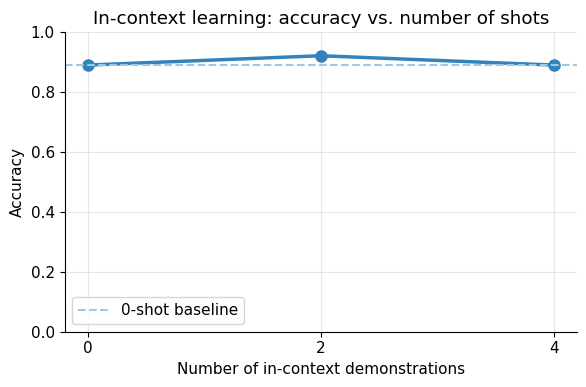

In [19]:
# ── 3.1  Few-shot prompting comparison ───────────────────────────────────────
# We use the first 8 training examples as our demonstration pool,
# then evaluate with 0, 2, and 4 shots.

few_shot_pool = [train_dataset[i] for i in range(8)]
shots_to_try  = [0, 2, 4]
shot_results  = {}

for n_shots in shots_to_try:
    demos = few_shot_pool[:n_shots]
    acc, _ = evaluate_model(base_model, eval_dataset, few_shot_examples=demos)
    shot_results[n_shots] = acc
    print(f'{n_shots}-shot accuracy: {acc:.3f}')

# Plot accuracy vs. number of in-context demonstrations
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(shots_to_try, [shot_results[n] for n in shots_to_try],
        marker='o', linewidth=2.5, markersize=8, color='#3182bd')
ax.axhline(baseline_accuracy, linestyle='--', color='#9ecae1', linewidth=1.5, label='0-shot baseline')
ax.set_xticks(shots_to_try)
ax.set_xlabel('Number of in-context demonstrations')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.0, 1.0)
ax.set_title('In-context learning: accuracy vs. number of shots')
ax.legend()
plt.tight_layout()
plt.show()

---

## 4. Finetune with LoRA

In-context learning helps, but it has limits: the context window is finite, and we cannot nudge model weights toward task-specific patterns. **LoRA** (Low-Rank Adaptation) offers a practical middle ground: instead of updating all 3 billion parameters, we insert a pair of small low-rank matrices into the attention layers and train only those. The rest of the model is frozen.

**How LoRA works:** for a weight matrix **W**, we add **ΔW = A × B** where **A** and **B** have rank *r* ≪ min(rows, cols). Only **A** and **B** are trained, typically representing **< 0.5 %** of the total parameter count. At inference time the trained adapter can be merged back into **W** at zero cost.

We convert each MMLU example into a prompt plus the correct single-letter answer. During training the prompt tokens are masked out of the loss (label = -100) so that the model is penalized only for the assistant turn — the letter it should predict.

In [ ]:
MAX_LENGTH = 256

def build_training_text(example):
    messages = [
        {'role': 'system',    'content': SYSTEM_PROMPT},
        {'role': 'user',      'content': build_user_prompt(example)},
        {'role': 'assistant', 'content': example['answerKey']},
    ]
    return render_messages(messages, add_generation_prompt=False)

def tokenize_supervised_example(example):
    prompt_text = render_messages(
        [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user',   'content': build_user_prompt(example)},
        ],
        add_generation_prompt=True,
    )
    full_text = build_training_text(example)

    prompt_ids    = tokenizer(prompt_text, add_special_tokens=False).input_ids
    tokenized     = tokenizer(full_text, truncation=True, max_length=MAX_LENGTH, padding='max_length')
    labels        = tokenized['input_ids'].copy()
    prompt_length = min(len(prompt_ids), MAX_LENGTH)
    labels[:prompt_length] = [-100] * prompt_length
    labels = [t if t != tokenizer.pad_token_id else -100 for t in labels]
    tokenized['labels'] = labels
    return tokenized

train_tokenized = train_dataset.map(tokenize_supervised_example, remove_columns=train_dataset.column_names)

# Free base model GPU memory before loading the LoRA copy
del base_model
if device.type == 'cuda':
    torch.cuda.empty_cache()

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias='none',
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj'],
)

finetuned_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch_dtype)
finetuned_model.to(device)
finetuned_model.config.use_cache = False
finetuned_model = get_peft_model(finetuned_model, lora_config)

total_params     = sum(p.numel() for p in finetuned_model.parameters())
trainable_params = sum(p.numel() for p in finetuned_model.parameters() if p.requires_grad)
print(f'Total parameters      : {total_params / 1e6:.1f}M')
print(f'Trainable (LoRA)      : {trainable_params / 1e3:.1f}K  ({100 * trainable_params / total_params:.2f}%)')
print()

training_kwargs = {
    'output_dir':                  str(OUTPUT_ROOT / 'qwen25_lora_mmlu'),
    'num_train_epochs':            3,
    'per_device_train_batch_size': 8 if device.type == 'cuda' else 1,
    'gradient_accumulation_steps': 2,
    'learning_rate':               2e-4,
    'warmup_ratio':                0.1,
    'lr_scheduler_type':           'cosine',
    'logging_steps':               5,
    'save_strategy':               'no',
    'report_to':                   'none',
    'fp16':                        device.type == 'cuda',
    'remove_unused_columns':       False,
}
supported_args  = inspect.signature(TrainingArguments.__init__).parameters
training_args   = TrainingArguments(**{k: v for k, v in training_kwargs.items() if k in supported_args})

trainer = Trainer(
    model=finetuned_model,
    args=training_args,
    train_dataset=train_tokenized,
    data_collator=default_data_collator,
)

trainer.train()
finetuned_model.eval()

# Plot training loss curve
log_history = [e for e in trainer.state.log_history if 'loss' in e]
if log_history:
    steps  = [e['step'] for e in log_history]
    losses = [e['loss']  for e in log_history]
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(steps, losses, color='#e6550d', linewidth=2)
    ax.set_xlabel('Training step')
    ax.set_ylabel('Loss')
    ax.set_title('LoRA training loss (Qwen 2.5 3B on MMLU)')
    plt.tight_layout()
    plt.show()

## 5. Evaluate, Compare, and Analyze

We rerun the same held-out evaluation on the finetuned model. Because prompts and metric are unchanged, any difference in accuracy is attributable directly to task-specific adaptation.

Beyond raw accuracy we also inspect:

- **Accuracy by method** — zero-shot baseline, few-shot prompting, and LoRA finetuning side by side.
- **Prediction distribution** — does the model have a letter bias (e.g. over-predicting A)?
- **Confidence margin** — is a larger margin between the top-scoring letter and the runner-up correlated with correctness?
- **Qualitative error analysis** — which examples did finetuning fix, and which remain hard?

In [ ]:
finetuned_accuracy, finetuned_rows = evaluate_model(finetuned_model, eval_dataset)

print(f'Zero-shot pretrained  : {baseline_accuracy:.3f}')
print(f'4-shot prompting      : {shot_results[4]:.3f}')
print(f'LoRA finetuned        : {finetuned_accuracy:.3f}')
print(f'Improvement (0-shot → LoRA): {finetuned_accuracy - baseline_accuracy:+.3f}')

# ── Three-panel comparison figure ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: Accuracy by method
method_labels = ['0-shot\n(pretrained)', '4-shot\n(prompting)', 'LoRA\n(finetuned)']
method_accs   = [baseline_accuracy, shot_results[4], finetuned_accuracy]
colors        = ['#9ecae1', '#6baed6', '#2171b5']
bars = axes[0].bar(method_labels, method_accs, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_ylim(0.0, 1.05)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy by method')
for bar, v in zip(bars, method_accs):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.02, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=10)

# Panel 2: Prediction distribution — check for letter bias
eval_labels = sorted(set(label for ex in eval_dataset for label in ex['labels']))
pre_dist  = Counter(r['pred'] for r in baseline_rows)
post_dist = Counter(r['pred'] for r in finetuned_rows)
x = range(len(eval_labels))
w = 0.35
axes[1].bar([i - w / 2 for i in x], [pre_dist.get(l, 0)  for l in eval_labels],
            w, label='Pretrained', color='#9ecae1')
axes[1].bar([i + w / 2 for i in x], [post_dist.get(l, 0) for l in eval_labels],
            w, label='Finetuned',  color='#2171b5')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(eval_labels)
axes[1].set_ylabel('Predicted count')
axes[1].set_title('Prediction distribution (label bias)')
axes[1].legend()

# Panel 3: Confidence margin vs. correctness
def collect_margins(rows):
    correct_m, wrong_m = [], []
    for r in rows:
        sorted_scores = sorted(r['scores'].values(), reverse=True)
        margin = sorted_scores[0] - sorted_scores[1]
        (correct_m if r['correct'] else wrong_m).append(margin)
    return correct_m, wrong_m

pre_c, pre_w   = collect_margins(baseline_rows)
post_c, post_w = collect_margins(finetuned_rows)
axes[2].hist(pre_w,  bins=12, alpha=0.55, color='#fc8d59', label='Pretrained — wrong')
axes[2].hist(post_c, bins=12, alpha=0.55, color='#2171b5', label='Finetuned — correct')
axes[2].set_xlabel('Log-prob margin (1st − 2nd best)')
axes[2].set_ylabel('Count')
axes[2].set_title('Confidence margin distribution')
axes[2].legend()

plt.suptitle('Qwen 2.5 3B on MMLU', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [22]:
# ── Qualitative error analysis ────────────────────────────────────────────────

fixed   = [(b, a) for b, a in zip(baseline_rows, finetuned_rows) if not b['correct'] and a['correct']]
broken  = [(b, a) for b, a in zip(baseline_rows, finetuned_rows) if b['correct'] and not a['correct']]
persist = [(b, a) for b, a in zip(baseline_rows, finetuned_rows) if not b['correct'] and not a['correct']]

print(f'Fixed by finetuning   : {len(fixed)}  (pretrained wrong → finetuned correct)')
print(f'Broken by finetuning  : {len(broken)}  (pretrained correct → finetuned wrong)')
print(f'Still wrong           : {len(persist)}  (both wrong)')
print()

print('─' * 70)
print('EXAMPLES FIXED BY FINETUNING')
print('─' * 70)
for before, after in fixed[:3]:
    print(f"Q: {before['question']}")
    print(before['choices'])
    print(f"Gold: {before['gold']}  |  Before: {before['pred']}  |  After: {after['pred']}")
    print()

print('─' * 70)
print('EXAMPLES STILL WRONG AFTER FINETUNING  (hard cases)')
print('─' * 70)
for before, after in persist[:3]:
    print(f"Q: {before['question']}")
    print(before['choices'])
    print(f"Gold: {before['gold']}  |  Before: {before['pred']}  |  After: {after['pred']}")
    print()

Fixed by finetuning   : 2  (pretrained wrong → finetuned correct)
Broken by finetuning  : 3  (pretrained correct → finetuned wrong)
Still wrong           : 5  (both wrong)

──────────────────────────────────────────────────────────────────────
EXAMPLES FIXED BY FINETUNING
──────────────────────────────────────────────────────────────────────
Q: Janette conducts an investigation to see which foods make her feel more fatigued. She eats one of four different foods each day at the same time for four days and then records how she feels. She asks her friend Carmen to do the same investigation to see if she gets similar results. Which would make the investigation most difficult to replicate?
A) measuring the amount of fatigue
B) making sure the same foods are eaten
C) recording observations in the same chart
D) making sure the foods are at the same temperature
Gold: A  |  Before: B  |  After: A

Q: Which apparatus would not be needed during an animal dissection?
A) gloves
B) goggles
C) lab sm

## 6. Call the OpenAI API and Inspect a Sample Response

Open-source models and hosted APIs fit different use cases. Finetuning a local model gives you direct control over training and evaluation, while a hosted API gives fast access to a stronger general-purpose model without managing checkpoints yourself.

The first cell below uses the modern `OpenAI` Python client for a normal text response. The second cell shows **structured outputs**, where the model is asked to return JSON that matches a schema so the result is easier to parse in downstream code.

In [ ]:
import os

from openai import OpenAI

if 'OPENAI_API_KEY' not in os.environ:
    raise RuntimeError('Set OPENAI_API_KEY before running this cell.')

client = OpenAI()
response = client.responses.create(
    model='gpt-5-mini',
    input='In a couple of sentences, explain why finetuning can improve task-specific performance for a small language model.',
)

print(response.output_text)

### 6.1 Structured Outputs

In many applications, free-form text is not enough. You may want a model to return a predictable object such as a label, a confidence score, and a short explanation. Structured outputs help with that by constraining the response to a schema.

The example below defines a small Pydantic class and asks the model to return data that matches it. The SDK then parses the response into a typed Python object, which is especially useful when the output will be consumed by another program instead of a human reader.

In [ ]:
from typing import Literal
from pydantic import BaseModel


class SentimentAnalysis(BaseModel):
    label: Literal['positive', 'negative']
    confidence: float
    summary: str


structured_response = client.responses.parse(
    model='gpt-5-mini',
    input=[
        {
            'role': 'system',
            'content': 'You are a sentiment analysis assistant. Return the answer using the requested structured format.',
        },
        {
            'role': 'user',
            'content': 'Analyze this review: "The movie starts slowly, but the performances and ending are excellent."',
        },
    ],
    text_format=SentimentAnalysis,
)

parsed = structured_response.output_parsed
print(parsed)
print()
print(f'label      : {parsed.label}')
print(f'confidence : {parsed.confidence:.2f}')
print(f'summary    : {parsed.summary}')